In [41]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

##Personal Imports##
from matplotlib.pyplot import plot, scatter, loglog,xlim, ylim, yscale, xscale, title, xlabel, ylabel

from numpy import pi, cos, sin, exp, log, sqrt, array
#import equilibrium_critical_correlations as ecc
from equilibrium_critical_correlations import P_n, sigma_general, P_n_correlations, Dn

In [47]:
correlator_data=[]
for n in range(1,11):

    path = "equilibrium_zproj_critical_correlation_data/"
    file_name = f"ZZ_corr_connected_n{n}_r00-199.npy"

    correlator_data.append(np.load(path+file_name))

correlator_data = np.array(correlator_data)

label_list = [f"n = {n}" for n in range(1,len(correlator_data)+1)]

r = np.arange(0,len(correlator_data[0]))

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21843/2449287704.py:7: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1.),label=r"$x^{-1}$",linestyle="--",color="black")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21843/2449287704.py:8: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1/4.),label=r"$x^{-1/2}$",linestyle=":",color="black")


[]

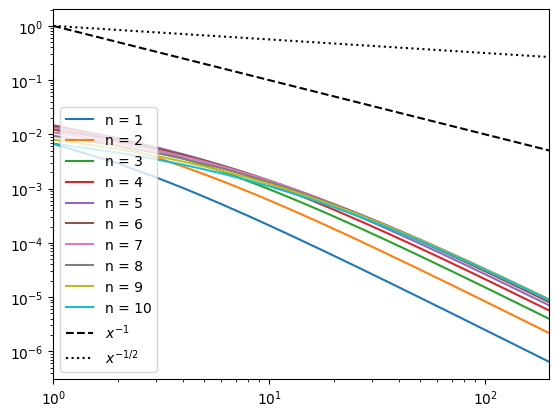

In [50]:
X = np.arange(0,len(correlator_data[0]))
P0 = correlator_data[0]
for i,p in enumerate(correlator_data):
    plot(X,p,label=f"{label_list[i]}")
    xlim(X[1],X[-1])

plot(X,X**(-1.),label=r"$x^{-1}$",linestyle="--",color="black")
plot(X,X**(-1/4.),label=r"$x^{-1/2}$",linestyle=":",color="black")
plt.legend()
loglog()

In [44]:
def large_r_scaling(r,A):
    return A*r**(-2.)

from scipy.optimize import curve_fit

weights= []
test = []
for P in correlator_data:
    A = curve_fit(large_r_scaling,X[150:],P[150:])[0]
    weights.append(A)
    test.append(np.abs(P-large_r_scaling(X,A)))

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21843/3260242490.py:2: RuntimeWarning: divide by zero encountered in power
  return A*r**(-2.)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21843/157383915.py:9: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-2.),label=r"$x^{-2}$",linestyle=":",color="black")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21843/157383915.py:10: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-3/4.)*correlator_data[-1][1]/weights[-1],label=r"$x^{-1/8}$",linestyle="--",color="black")


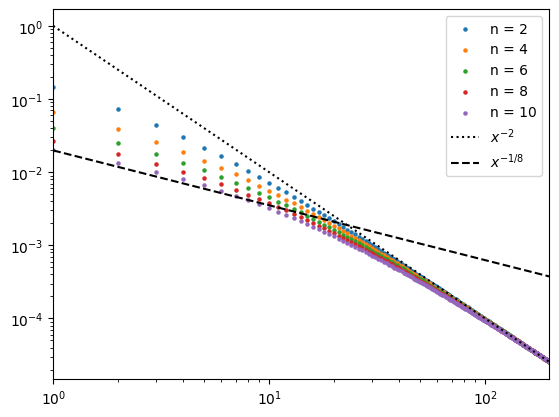

In [45]:
X = np.arange(0,len(correlator_data[0]))
P0 = correlator_data[0]
for i,p in enumerate(correlator_data):
    if i %2 !=0:
        w = weights[i]
        scatter(X,(p)/w,label=f"{label_list[i]}",s=5)
        xlim(X[1],X[-1])

plot(X,X**(-2.),label=r"$x^{-2}$",linestyle=":",color="black")
plot(X,X**(-3/4.)*correlator_data[-1][1]/weights[-1],label=r"$x^{-1/8}$",linestyle="--",color="black")

loglog()
plt.legend()


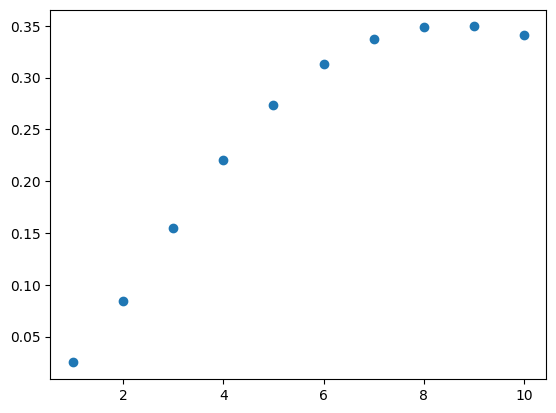

In [46]:
r= np.array([1,2,3,4,5,6,7,8,9,10])
scatter(r,weights)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21843/2751963257.py:10: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1.)*test[1][1],label=r"$x^{-1}$",linestyle=":",color="black")


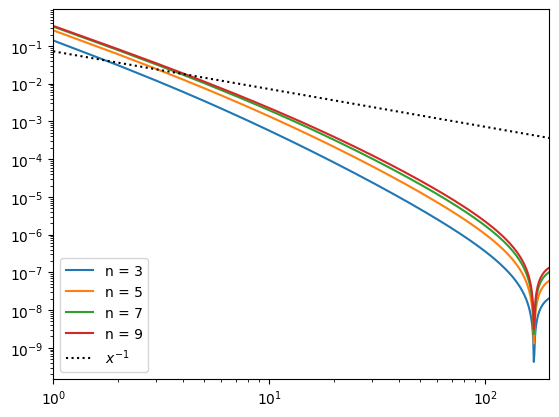

In [22]:
P0 = correlator_data[0]
for i,p in enumerate(correlator_data):
    if i ==0:
        pass
    elif i%2==0:
        w = weights[i]
        plot(X,test[i],label=f"{label_list[i]}")
        xlim(X[1],X[-1])
#plot(X,X**(-2.)*test[1][1],label=r"$x^{-2}$",linestyle="--",color="black")
plot(X,X**(-1.)*test[1][1],label=r"$x^{-1}$",linestyle=":",color="black")
plt.legend()
loglog()
plt.show()

[array([0.02136356, 1.        ]), array([0.02822619, 1.        ]), array([0.02942992, 1.        ]), array([0.0280363, 1.       ]), array([0.02549463, 1.        ]), array([0.02254394, 1.        ]), array([0.01956945, 1.        ]), array([0.01676718, 1.        ])]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_74791/1878553676.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  A = curve_fit(small_r_scaling,X[1:50],test[i][1:50])[0]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_74791/1878553676.py:2: RuntimeWarning: divide by zero encountered in power
  return A*r**(-1.)


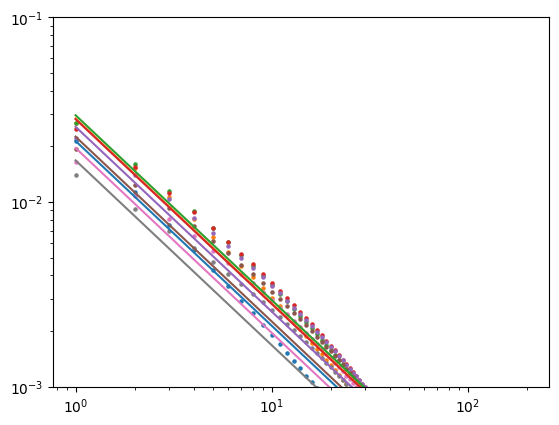

In [11]:
def small_r_scaling(r,A,b):
    return A*r**(-1.)

from scipy.optimize import curve_fit

weights_2= []
for i in range(1,len(test)):
    A = curve_fit(small_r_scaling,X[1:50],test[i][1:50])[0]
    plot(X,small_r_scaling(X,*A),label=f"{i+1}")
    scatter(X,test[i],s=5)
    weights_2.append(A)
loglog()
ylim(.001,.1)
print(weights_2)
#legend()

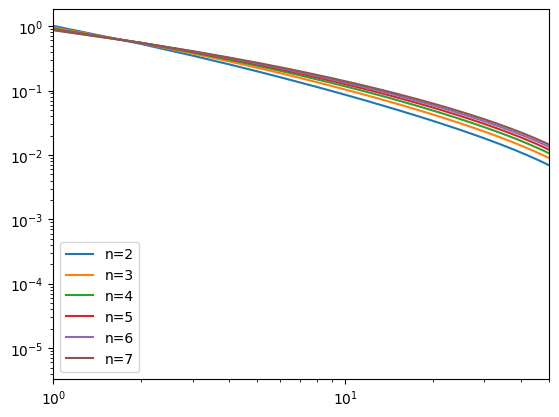

In [130]:
P0 = correlations[0]
for i,p in enumerate(correlations):
    if i ==0:
        pass
    else:
        w = weights_2[i]
        plot(X,test[i]/w,label=f"n={ns[i]}")
        xlim(X[1],X[-1])
plt.xlim(1,50)
#plot(X,X**(-2.)*test[1][1],label=r"$x^{-2}$",linestyle="--",color="black")
#plot(X,X**(-1.)*test[1][1],label=r"$x^{-1/4}$",linestyle=":",color="black")
plt.legend()
loglog()
plt.show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_70673/248569487.py:7: RuntimeWarning: divide by zero encountered in power
  plot(X,X**(-1/4.),label=r"$x^{-1/4}$",linestyle=":",color="black")


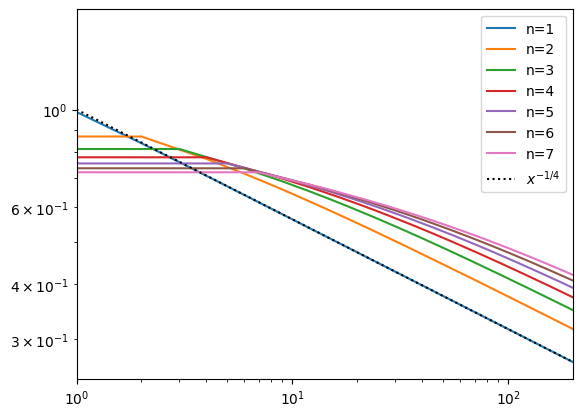

In [159]:
X = np.arange(0,len(correlations[0]))
P0 = correlations[0]
for i,p in enumerate(correlations):
    w = weights[i]
    plot(X*(i+1),(p)/w,label=f"n={ns[i]}")
    xlim(X[1],X[-1])
plot(X,X**(-1/4.),label=r"$x^{-1/4}$",linestyle=":",color="black")
loglog()
legend()
plt.show()


